# Introduction

Let us build a Small Language Model (SLM) from scratch. We will try to keep the parameter size to 50-60 million.

Our goal is to generate creative and coherent text based on the input data.

## Step 1: Import the Dataset

TinyStories is a synthetic dataset of short stories that only contain words that a typical 3 to 4-year-olds usually understand, generated by GPT-3.5 and GPT-4. We can get it from HuggingFace.

In [ ]:
!pip install -q datasets

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_DIR = "/content/drive/MyDrive/FinSLM"
os.makedirs(DRIVE_DIR, exist_ok=True)

print(f"Drive mounted. Working dir: {DRIVE_DIR}")
print("Contents:", os.listdir(DRIVE_DIR))

Mounted at /content/drive
Drive mounted. Working dir: /content/drive/MyDrive/FinSLM
Contents: ['validation.bin', 'train.bin', 'best_model.pt', 'loss_log.json', 'checkpoint.pt', 'loss_curve.png', 'perplexity.png', 'lr_schedule.png', 'val_delta.png', 'grad_norm.png', 'sample_outputs.txt']


In [ ]:
# Load & Combine Financial News Datasets
from datasets import load_dataset, concatenate_datasets, DatasetDict

print("Loading datasets...")

bloomberg  = load_dataset("danidanou/Bloomberg_Financial_News", split="train")
ashraq_fin = load_dataset("ashraq/financial-news-articles",    split="train")
indian_fin = load_dataset("kdave/Indian_Financial_News",       split="train")

bloomberg_col = "text" if "text" in bloomberg.column_names else "Article"
bloomberg_c = bloomberg.map(lambda ex: {"text": str(ex[bloomberg_col] or "")},
                            remove_columns=bloomberg.column_names)
ashraq_c    = ashraq_fin.map(lambda ex: {"text": str(ex["text"] or "")},
                              remove_columns=ashraq_fin.column_names)
indian_c    = indian_fin.map(lambda ex: {"text": str(ex["Content"] or "")},
                              remove_columns=indian_fin.column_names)

MIN_CHARS = 100
bloomberg_c = bloomberg_c.filter(lambda ex: len(ex["text"]) > MIN_CHARS)
ashraq_c    = ashraq_c.filter(lambda ex: len(ex["text"]) > MIN_CHARS)
indian_c    = indian_c.filter(lambda ex: len(ex["text"]) > MIN_CHARS)

combined = concatenate_datasets([bloomberg_c, ashraq_c, indian_c])
split    = combined.train_test_split(test_size=0.02, seed=42)
ds = DatasetDict({"train": split["train"], "validation": split["test"]})

print(f"Train:      {len(ds['train']):,}")
print(f"Validation: {len(ds['validation']):,}")

# Quick corpus stats
import numpy as np
sample_lengths = [len(ex["text"].split()) for ex in ds["train"].select(range(5000))]
print(f"\nAvg words/article: {np.mean(sample_lengths):.0f}")
print(f"Median words/article: {np.median(sample_lengths):.0f}")

Loading datasets...


Generating train split:   0%|          | 0/446762 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/543 [00:00<?, ?B/s]

data/train-00000-of-00002-a3f58f0eb179f9(…):   0%|          | 0.00/238M [00:00<?, ?B/s]

data/train-00001-of-00002-50e0d6558d1357(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

...

Map:   0%|          | 0/26961 [00:00<?, ? examples/s]

Filter:   0%|          | 0/446762 [00:00<?, ? examples/s]

Filter:   0%|          | 0/306242 [00:00<?, ? examples/s]

Filter:   0%|          | 0/26961 [00:00<?, ? examples/s]

Train:      760,006
Validation: 15,511

Avg words/article: 423
Median words/article: 299


## Step 2: Tokenize the Dataset

In this step, we will do the following:

(1) Tokenize the dataset into tokenIDs.

(2) Create a file called "train.bin" and "validtion.bin" where we will store the tokenIDs from the entire dataset.

(3) We make sure the tokenIDs are stored on a disk, rather than on the RAM for efficient computations.

In [3]:
# Tokenize & Write .bin — with Drive backup
import tiktoken, os, numpy as np
from tqdm.auto import tqdm

enc = tiktoken.get_encoding("gpt2")

TRAIN_BIN = "train.bin"
VAL_BIN   = "validation.bin"
DRIVE_TRAIN = os.path.join(DRIVE_DIR, "train.bin")
DRIVE_VAL   = os.path.join(DRIVE_DIR, "validation.bin")

def process(example):
    ids = enc.encode_ordinary(example["text"])
    return {"ids": ids, "len": len(ids)}

# Re-use from drive if already tokenized
if os.path.exists(DRIVE_TRAIN) and os.path.exists(DRIVE_VAL):
    print("Found tokenized .bin files in Drive — copying locally...")
    import shutil
    shutil.copy(DRIVE_TRAIN, TRAIN_BIN)
    shutil.copy(DRIVE_VAL,   VAL_BIN)
    print("Done. Skipping re-tokenization.")
else:
    print("Tokenizing from scratch...")
    tokenized = ds.map(process, remove_columns=["text"],
                       desc="tokenizing", num_proc=4)

    split_map = {"train": (TRAIN_BIN, DRIVE_TRAIN),
                 "validation": (VAL_BIN, DRIVE_VAL)}

    for split_name, (local_path, drive_path) in split_map.items():
        dset = tokenized[split_name]
        arr_len = np.sum(dset["len"], dtype=np.uint64)
        arr = np.memmap(local_path, dtype=np.uint16, mode="w+", shape=(arr_len,))
        total_batches = 512
        idx = 0
        for b in tqdm(range(total_batches), desc=f"writing {local_path}"):
            batch = dset.shard(num_shards=total_batches, index=b,
                               contiguous=True).with_format("numpy")
            chunk = np.concatenate(batch["ids"])
            arr[idx: idx + len(chunk)] = chunk
            idx += len(chunk)
        arr.flush()
        import shutil
        shutil.copy(local_path, drive_path)
        print(f"Saved {local_path} → Drive ({arr_len:,} tokens)")

# Verify sizes
train_data = np.memmap(TRAIN_BIN,   dtype=np.uint16, mode="r")
val_data   = np.memmap(VAL_BIN,     dtype=np.uint16, mode="r")
print(f"\nTrain tokens: {len(train_data):,}  ({len(train_data)/1e6:.1f}M)")
print(f"Val tokens:   {len(val_data):,}  ({len(val_data)/1e6:.1f}M)")

Found tokenized .bin files in Drive — copying locally...
Done. Skipping re-tokenization.

Train tokens: 480,451,434  (480.5M)
Val tokens:   9,921,440  (9.9M)


## Step 3: Create Input-Output batches for the dataset

In [4]:
# Some functions from https://github.com/karpathy/nanoGPT/blob/master/train.py with slight modifications
# block size = context window
def get_batch(split):
    # We recreate np.memmap every batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
    if split == 'train':
        data = np.memmap('train.bin', dtype=np.uint16, mode='r')
    else:
        data = np.memmap('validation.bin', dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y


## Step 4: Define the SLM Model Architecture

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass
import numpy as np
from tqdm.auto import tqdm
from contextlib import nullcontext
import os

class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                       .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        if self.flash:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=self.attn_dropout.p if self.training else 0.0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2 = LayerNorm(config.n_embd, config.bias)
        self.mlp = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int
    vocab_size: int
    n_layer: int
    n_head: int
    n_embd: int
    dropout: float = 0.0
    bias: bool = True

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f=LayerNorm(config.n_embd, config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight  # weight tying

        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size
        pos = torch.arange(0, t, dtype=torch.long, device=device)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
            return logits, loss
        else:
            logits = self.lm_head(x[:, [-1], :])
            return logits, None

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        Generate tokens given a conditioning sequence.
        idx: Tensor of shape (B, T)
        """
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


In [6]:
config = GPTConfig(
    vocab_size=50257,     # use the tokenizer's vocab size
    block_size=128,       # or whatever context size you're training with
    n_layer=6,
    n_head=6,
    n_embd=384,
    dropout=0.1,
    bias=True
)

model = GPT(config)

# Parameter count
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters:     {total_params/1e6:.2f}M")
print(f"Embedding dim:        {config.n_embd}")
print(f"Layers:               {config.n_layer}")
print(f"Heads:                {config.n_head}")
print(f"Context length:       {config.block_size} tokens")


Total parameters:     30.00M
Embedding dim:        384
Layers:               6
Heads:                6
Context length:       128 tokens


## Step 5: Define the loss function

In [7]:
def estimate_loss(model):
    out = {}
    model.eval()
    with torch.inference_mode():
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                with ctx:
                    logits, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
    model.train()
    return out

## Step 6: Define SLM Training Configuration Part 1

In [12]:
# Training Config
import torch
from contextlib import nullcontext

# Core hyperparameters
learning_rate = 1e-4          # standard for AdamW on small transformers
max_iters     = 60000
warmup_steps  = 1000           # enough for stable warmup
min_lr        = 1e-5          # MUST be < learning_rate for cosine decay to work
eval_iters    = 500           # how many batches to avg over at each eval point
eval_interval = 500           # evaluate every N iters
batch_size    = 32
block_size    = config.block_size

gradient_accumulation_steps = 32 # was set to 4 for the first run

# Checkpoint / Drive config
ckpt_save_interval = 500           # save checkpoint to Drive every N iters
CKPT_PATH          = os.path.join(DRIVE_DIR, "checkpoint.pt")
LOSS_LOG_PATH      = os.path.join(DRIVE_DIR, "loss_log.json")

# Early stopping
early_stop_patience = 8            # stop if val loss doesn't improve for 8 evals

# Device / dtype
device      = "cuda" if torch.cuda.is_available() else "cpu"
device_type = "cuda" if "cuda" in device else "cpu"

# How to use autocast https://wandb.ai/wandb_fc/tips/reports/How-To-Use-Autocast-in-PyTorch--VmlldzoyMTk4NTky
# dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
dtype   = "float16"
ptdtype = torch.float16
ctx     = nullcontext() if device_type == "cpu" else torch.amp.autocast(device_type=device_type, dtype=ptdtype)


torch.set_default_device(device)
torch.manual_seed(42)

print(f"Device: {device}")
print(f"dtype:  {dtype}")
print(f"Effective batch size: {batch_size * gradient_accumulation_steps} sequences "
      f"= {batch_size * gradient_accumulation_steps * block_size:,} tokens")
print(f"Eval every {eval_interval} iters | Save checkpoint every {ckpt_save_interval} iters")
print(f"Early stop patience: {early_stop_patience} evals = "
      f"{early_stop_patience * eval_interval} iters")

Device: cuda
dtype:  float16
Effective batch size: 1024 sequences = 131,072 tokens
Eval every 500 iters | Save checkpoint every 500 iters
Early stop patience: 8 evals = 4000 iters


## Step 7: Define SLM Training Configuration Part 2

In [13]:
# Optimizer & Scheduler
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    betas=(0.9, 0.95),
    weight_decay=0.1, # weight decay for regularization
    eps=1e-9,
)

scheduler_warmup = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_steps) # Implement linear warmup
scheduler_decay  = CosineAnnealingLR(optimizer, T_max=max_iters - warmup_steps, eta_min=min_lr) # Implement lr decay
scheduler        = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_decay], milestones=[warmup_steps])

# https://stackoverflow.com/questions/72534859/is-gradscaler-necessary-with-mixed-precision-training-with-pytorch
scaler = torch.amp.GradScaler('cuda', enabled=(dtype == 'float16'))


## Step 8: Pre-train the SLM

In [14]:
import json, time, shutil, math

# Checkpoint resume
start_iter = 0
best_val_loss = float("inf")
train_loss_list, val_loss_list, lr_list, iter_list, grad_norm_list = [], [], [], [], []
no_improve_count = 0

BEST_CKPT   = os.path.join(DRIVE_DIR, "best_model.pt")
LATEST_CKPT = os.path.join(DRIVE_DIR, "checkpoint.pt")

# Ensure model is on the correct device
model = model.to(device)

if os.path.exists(LATEST_CKPT):
    print(f"Resuming from checkpoint: {LATEST_CKPT}")
    ckpt = torch.load(LATEST_CKPT, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    # scaler.load_state_dict(ckpt["scaler"])
    start_iter       = ckpt["iter"] + 1
    best_val_loss    = ckpt["best_val_loss"]
    no_improve_count = ckpt.get("no_improve_count", 0)
    optimizer.zero_grad(set_to_none=True)

    # Align to next accumulation boundary to avoid mid-cycle resume
    remainder = start_iter % gradient_accumulation_steps
    if remainder != 0:
        start_iter = start_iter + (gradient_accumulation_steps - remainder)
    print(f"  Aligned start_iter to {start_iter}")

    # Restore loss history
    if os.path.exists(LOSS_LOG_PATH):
        with open(LOSS_LOG_PATH) as f:
            log = json.load(f)
        train_loss_list  = log.get("train", [])
        val_loss_list    = log.get("val", [])
        lr_list          = log.get("lr", [])
        iter_list        = log.get("iters", [])
        grad_norm_list   = log.get("grad_norm", [])
    print(f"Resumed at iter {start_iter}, best_val_loss={best_val_loss:.4f}")
else:
    print("No checkpoint found — starting fresh.")

# Training loop
last_gnorm = 0.0
t_start = time.time()

for iter_num in range(start_iter, max_iters):
    # Evaluation block
    if iter_num % eval_interval == 0:
        losses = estimate_loss(model)
        cur_lr = optimizer.param_groups[0]["lr"]
        elapsed = (time.time() - t_start) / 60

        print(f"[iter {iter_num:>6}]  "
              f"train={losses['train']:.4f}  val={losses['val']:.4f}  "
              f"lr={cur_lr:.2e}  elapsed={elapsed:.1f}min")

        train_loss_list.append(losses["train"])
        val_loss_list.append(losses["val"])
        lr_list.append(cur_lr)
        iter_list.append(iter_num)
        grad_norm_list.append(last_gnorm)

        # Best model save
        if losses["val"] < best_val_loss:
            best_val_loss    = losses["val"]
            no_improve_count = 0
            torch.save(model.state_dict(), BEST_CKPT)
            print(f"  ✓ New best val loss {best_val_loss:.4f}")
        else:
            no_improve_count += 1
            print(f"  ✗ No improvement ({no_improve_count}/{early_stop_patience})")

        # Save loss log to Drive
        with open(LOSS_LOG_PATH, "w") as f:
          json.dump({
              "train": [x.item() if hasattr(x, 'item') else float(x) for x in train_loss_list],
              "val":   [x.item() if hasattr(x, 'item') else float(x) for x in val_loss_list],
              "lr":    [float(x) for x in lr_list],
              "iters": iter_list,
              "grad_norm": [float(x) for x in grad_norm_list]
          }, f)

        # Early stopping
        if no_improve_count >= early_stop_patience:
            print(f"\nEarly stopping triggered at iter {iter_num}. "
                  f"Best val loss: {best_val_loss:.4f}")
            break

    # Periodic full checkpoint to Drive
    if iter_num % ckpt_save_interval == 0 and iter_num > start_iter:
        ckpt = {
            "iter":            iter_num,
            "model":           model.state_dict(),
            "optimizer":       optimizer.state_dict(),
            "scheduler":       scheduler.state_dict(),
            "scaler":          scaler.state_dict(),
            "best_val_loss":   best_val_loss,
            "no_improve_count": no_improve_count,
            "config":          config,
        }
        torch.save(ckpt, LATEST_CKPT)
        print(f"  Checkpoint saved to Drive at iter {iter_num}")

    # Forward / backward pass
    X, y = get_batch("train")
    X, y = X.to(device), y.to(device)

    with ctx:
        logits, loss = model(X, y)
        loss_scaled  = loss / gradient_accumulation_steps
        scaler.scale(loss_scaled).backward()

    if (iter_num + 1) % gradient_accumulation_steps == 0:
        # Unscale before clipping
        scaler.unscale_(optimizer)
        gnorm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        last_gnorm = gnorm.item()

        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
    scheduler.step()

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

Resuming from checkpoint: /content/drive/MyDrive/FinSLM/checkpoint.pt
  Aligned start_iter to 39520
Resumed at iter 39520, best_val_loss=4.3263
[iter  40000]  train=4.2947  val=4.3053  lr=9.97e-05  elapsed=1.5min
  ✓ New best val loss 4.3053
  Checkpoint saved to Drive at iter 40000
[iter  40500]  train=4.2723  val=4.2868  lr=9.93e-05  elapsed=3.0min
  ✓ New best val loss 4.2868
  Checkpoint saved to Drive at iter 40500
[iter  41000]  train=4.2774  val=4.2835  lr=9.87e-05  elapsed=4.6min
  ✓ New best val loss 4.2835
  Checkpoint saved to Drive at iter 41000
[iter  41500]  train=4.2497  val=4.2847  lr=9.80e-05  elapsed=6.1min
  ✗ No improvement (1/8)
  Checkpoint saved to Drive at iter 41500
[iter  42000]  train=4.2460  val=4.2583  lr=9.71e-05  elapsed=7.6min
  ✓ New best val loss 4.2583
  Checkpoint saved to Drive at iter 42000
[iter  42500]  train=4.2198  val=4.2410  lr=9.60e-05  elapsed=9.1min
  ✓ New best val loss 4.2410
  Checkpoint saved to Drive at iter 42500
[iter  43000]  train

## Step 9: Plot the SLM Loss Function

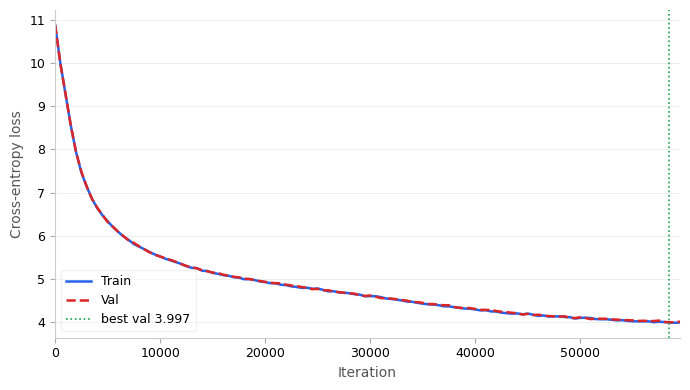

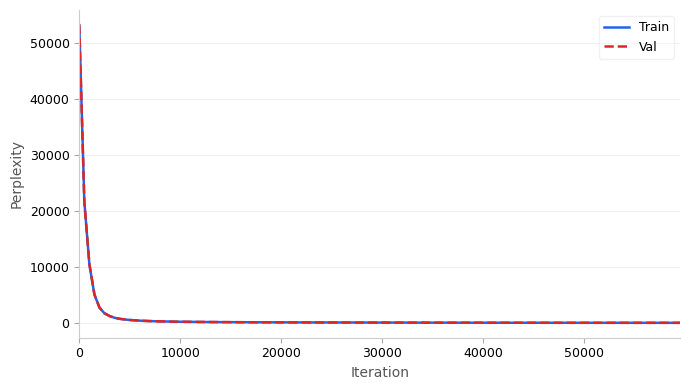

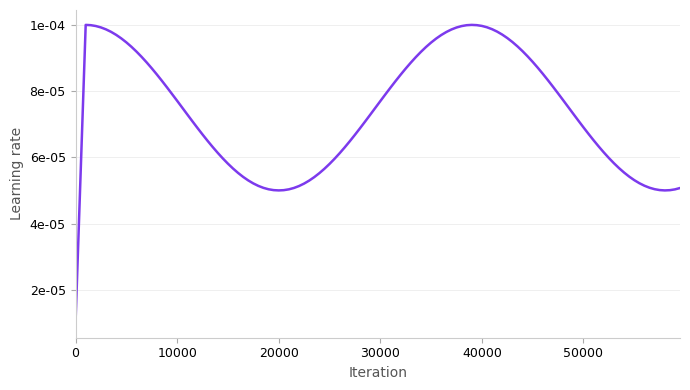

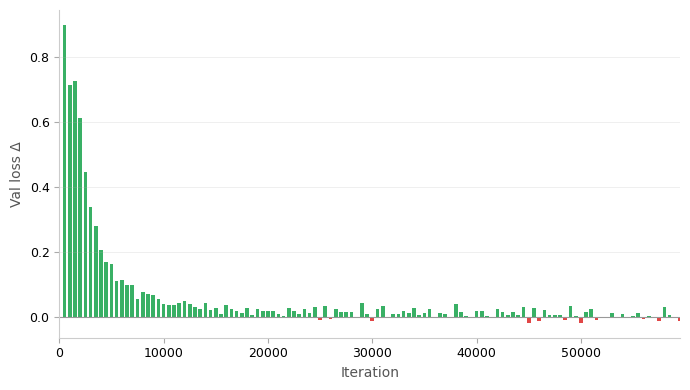

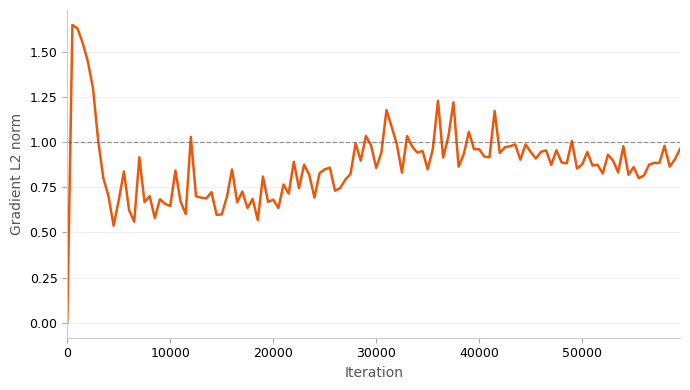


Plots saved: ['loss_curve', 'perplexity', 'lr_schedule', 'val_delta', 'grad_norm']


In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np, json, math, os

# Load from log file if running in a fresh session after crash
if not train_loss_list and os.path.exists(LOSS_LOG_PATH):
    with open(LOSS_LOG_PATH) as f:
        log = json.load(f)
    train_loss_list = log["train"]
    val_loss_list   = log["val"]
    lr_list         = log["lr"]
    iter_list       = log["iters"]
    grad_norm_list  = log.get("grad_norm", [0]*len(train_loss_list))

train_loss_list = [x.cpu().item() if hasattr(x, 'cpu') else float(x) for x in train_loss_list]
val_loss_list   = [x.cpu().item() if hasattr(x, 'cpu') else float(x) for x in val_loss_list]
lr_list         = [float(x) for x in lr_list]
grad_norm_list  = [float(x) for x in grad_norm_list]

iters = iter_list if iter_list else list(range(0, len(train_loss_list) * 500, 500))

PLOT_DIR = DRIVE_DIR
STYLE = dict(linewidth=1.8)

def base_ax(ax, xlabel="Iteration"):
    ax.set_xlabel(xlabel, fontsize=10, color="#555")
    ax.tick_params(labelsize=9, color="#aaa")
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["left","bottom"]].set_color("#ccc")
    ax.grid(axis="y", alpha=0.2, linewidth=0.7)
    ax.set_xlim(iters[0], iters[-1])

# 1. Train vs Val Loss
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(iters, train_loss_list, color="#2563eb", label="Train", **STYLE)
ax.plot(iters, val_loss_list,   color="#dc2626", label="Val", linestyle="--", **STYLE)
ax.fill_between(iters, train_loss_list, val_loss_list, alpha=0.06, color="#dc2626")
best_idx = int(np.argmin(val_loss_list))
ax.axvline(iters[best_idx], color="#16a34a", lw=1.2, linestyle=":",
           label=f"best val {val_loss_list[best_idx]:.3f}")
base_ax(ax)
ax.set_ylabel("Cross-entropy loss", fontsize=10, color="#555")
ax.legend(fontsize=9, framealpha=0.4, edgecolor="#ddd")
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "loss_curve.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print()

# 2. Perplexity
fig, ax = plt.subplots(figsize=(7, 4))
train_ppl = [math.exp(min(l, 20)) for l in train_loss_list]
val_ppl   = [math.exp(min(l, 20)) for l in val_loss_list]
ax.plot(iters, train_ppl, color="#2563eb", label="Train", **STYLE)
ax.plot(iters, val_ppl,   color="#dc2626", label="Val", linestyle="--", **STYLE)
base_ax(ax)
ax.set_ylabel("Perplexity", fontsize=10, color="#555")
ax.legend(fontsize=9, framealpha=0.4, edgecolor="#ddd")
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, "perplexity.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print()

# 3. Learning Rate Schedule
if lr_list:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(iters, lr_list, color="#7c3aed", **STYLE)
    base_ax(ax)
    ax.set_ylabel("Learning rate", fontsize=10, color="#555")
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0e'))
    fig.tight_layout()
    fig.savefig(os.path.join(PLOT_DIR, "lr_schedule.png"), dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print()

# 4. Val loss delta (improvement per eval)
if len(val_loss_list) > 1:
    fig, ax = plt.subplots(figsize=(7, 4))
    deltas = [val_loss_list[i-1] - val_loss_list[i] for i in range(1, len(val_loss_list))]
    colors = ["#16a34a" if d > 0 else "#dc2626" for d in deltas]
    bar_w  = (iters[-1] - iters[0]) / len(deltas) * 0.7
    ax.bar(iters[1:], deltas, color=colors, width=bar_w, alpha=0.85)
    ax.axhline(0, color="#999", lw=0.8)
    base_ax(ax)
    ax.set_ylabel("Val loss Δ", fontsize=10, color="#555")
    fig.tight_layout()
    fig.savefig(os.path.join(PLOT_DIR, "val_delta.png"), dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print()

# 5. Gradient norm
if any(g > 0 for g in grad_norm_list):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(iters[:len(grad_norm_list)], grad_norm_list,
            color="#ea580c", **STYLE)
    ax.axhline(1.0, color="#555", lw=0.9, linestyle="--", alpha=0.6, label="clip threshold")
    base_ax(ax)
    ax.set_ylabel("Gradient L2 norm", fontsize=10, color="#555")
    fig.tight_layout()
    fig.savefig(os.path.join(PLOT_DIR, "grad_norm.png"), dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print()

print("Plots saved:", ["loss_curve","perplexity","lr_schedule","val_delta","grad_norm"])

## Step 10: Run SLM Inference on our trained model

In [16]:
import tiktoken
enc = tiktoken.get_encoding("gpt2")

# Load best model
device = "cuda" if torch.cuda.is_available() else "cpu"
model_eval = GPT(config).to(device) # re-create the model with same config
model_eval.load_state_dict(torch.load(BEST_CKPT, map_location=torch.device(device))) # load best model states
model_eval.eval()

PROMPTS = [
    "The Federal Reserve raised interest rates by",
    "Reliance Industries reported a quarterly profit of",
    "The Sensex fell sharply after",
    "Inflation in India reached",
    "Goldman Sachs analysts warned that",
    "The merger between",
]

def generate_text(prompt, max_new_tokens=120, temperature=0.8, top_k=50):
    ids  = enc.encode_ordinary(prompt)
    idx  = torch.tensor([ids], dtype=torch.long, device=device)
    with torch.no_grad():
        out = model_eval.generate(idx, max_new_tokens=max_new_tokens,
                                  temperature=temperature, top_k=top_k)
    return enc.decode(out[0].tolist())

print("─" * 70)
print("QUALITATIVE OUTPUTS — FinSLM")
print("─" * 70)
results = {}
for prompt in PROMPTS:
    output = generate_text(prompt)
    results[prompt] = output
    print(f"\nPROMPT: {prompt}")
    print(f"OUTPUT: {output}")
    print("-" * 70)

# Temperature ablation on one prompt
print("\n\nTEMPERATURE ABLATION")
print("─" * 70)
probe = "The stock market declined after"
for temp in [0.5, 0.8, 1.0, 1.2]:
    out = generate_text(probe, temperature=temp)
    print(f"\ntemp={temp}: {out}")
    print("-" * 70)

# Save to Drive
with open(os.path.join(DRIVE_DIR, "sample_outputs.txt"), "w") as f:
    for p, o in results.items():
        f.write(f"PROMPT: {p}\nOUTPUT: {o}\n\n{'='*70}\n\n")
print("\nSample outputs saved to Drive.")

──────────────────────────────────────────────────────────────────────
QUALITATIVE OUTPUTS — FinSLM
──────────────────────────────────────────────────────────────────────

PROMPT: The Federal Reserve raised interest rates by
OUTPUT: The Federal Reserve raised interest rates by a record low of $29.35 trillion through Sept. 17, according to data compiled by Bloomberg. The Bank of America Merrill Lynch U.S. policy-banking Index has dropped 1.9 percent this year to $14.15 on the Comex in New York. The Fed’s outlook for the central bank may release the financial crisis, with a 0.4 percent yield on the central bank’s 1.09 percent rate, according to the median estimate of economists surveyed by Bloomberg. The median forecast for a 0.1 percent slump in the past year is the
----------------------------------------------------------------------

PROMPT: Reliance Industries reported a quarterly profit of
OUTPUT: Reliance Industries reported a quarterly profit of $1.8 billion. “The new year is a s